In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [2]:
# --- 0) Imports, configuración, utilidades ---
import os
from pathlib import Path

import numpy as np
import xarray as xr
import dask.array as da
from dask.diagnostics import ProgressBar
import pandas as pd
import matplotlib.pyplot as plt

from spectralcrop import PathManager

INTERIM_DATA = PathManager().get_abs_path_folder("interim")
FIGURES_FOLDER = PathManager().get_abs_path_folder("figures")
ZARR_PATH = INTERIM_DATA + "masked_reflectance.zarr"
REPORTS_DIR = INTERIM_DATA + "reports"
INDICES_DIR = REPORTS_DIR + "/indices"
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(INDICES_DIR, exist_ok=True)

RNG = np.random.default_rng(42)

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

def nearest_band_index(wavelengths_nm, target_nm):
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    idx = int(np.abs(wavelengths_nm - target_nm).argmin())
    return idx, float(wavelengths_nm[idx])

In [3]:
REPORTS_DIR

'c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\data\\interim\\reports'

In [ ]:
# --- 1) Abrir Zarr e inspección ---

ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")

C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_4900\2447719859.py:3: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})
C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_4900\2447719859.py:3: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})


<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\dask\array\reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


In [6]:
# --- 3) Mapa de NoData ---
# Definición: pixel es NoData si en alguna banda hay NaN
mask_nodata = xr.where(xr.ufuncs.isnan(refl_byx).any(dim="band"), 1, 0).astype("uint8")
mask_nodata.name = "mask_nodata"
mask_nodata.to_dataset().to_zarr(REPORTS_DIR + "/mask_nodata.zarr", mode="w")

total_px = refl_byx.sizes["y"] * refl_byx.sizes["x"]
nodata_count = int(mask_nodata.sum().compute())
print(f"Pixeles NoData: {nodata_count} ({nodata_count/total_px:.2%})")

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Pixeles NoData: 6484992 (51.54%)


Se tiene que del total de pixeles originales, 51.54% no poseen datos ya que o se encuentran en una zona externa a la imagen capturada o los pixeles son clasificados como información inválida (150000)

In [7]:
# --- 4) Validación NDVI/veg_mask ---
# Quick stats para confirmar consistencia
ndvi_stats = ndvi.where(~xr.ufuncs.isnan(ndvi)).quantile([0.01, 0.5, 0.99]).compute()
veg_ratio = float(veg_mask.mean().compute())
print("NDVI percentiles [1%, 50%, 99%]:", to_numpy(ndvi_stats).round(3))
print(f"Proporción de vegetación (veg_mask==True): {veg_ratio:.2%}")

NDVI percentiles [1%, 50%, 99%]: [0.32  0.865 0.927]
Proporción de vegetación (veg_mask==True): 48.70%


Pixeles NoData: 6,484,992 (51.54%)


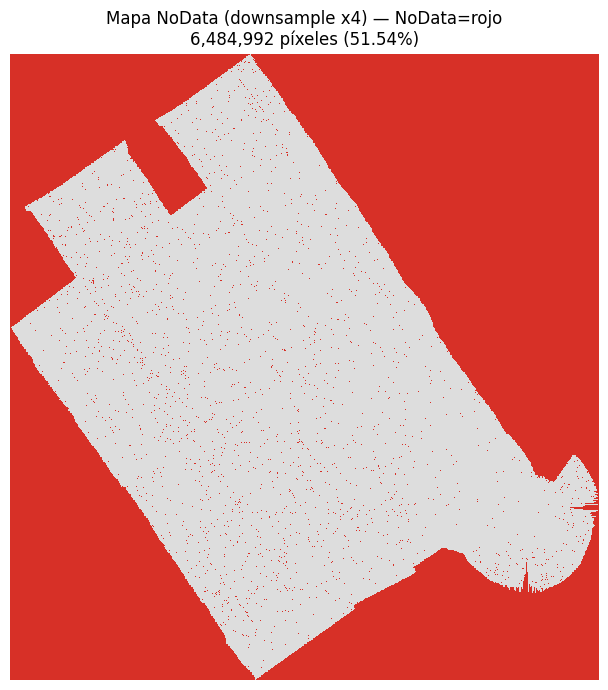

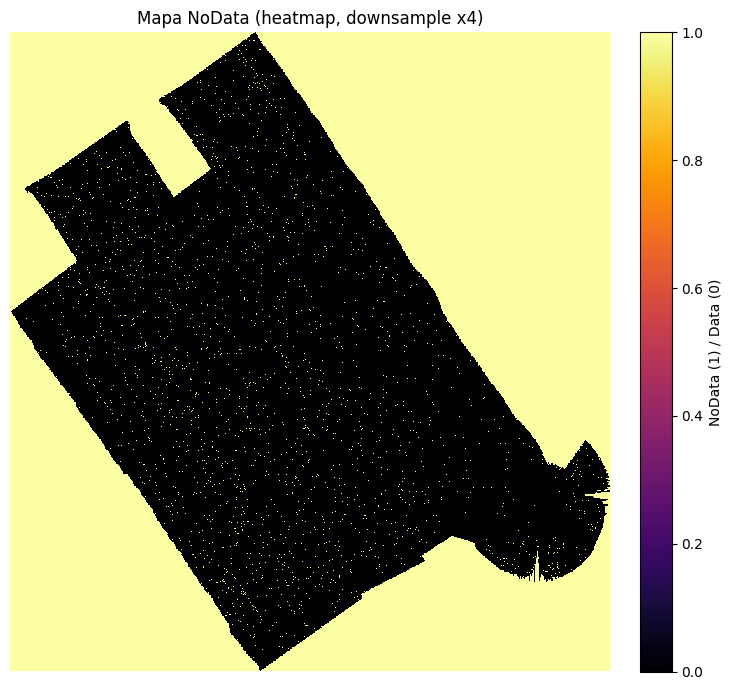

In [8]:
# --- Mapa visual de píxeles NoData (y superposición opcional de veg_mask) ---

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1) Abrir Zarr y preparar datos

# reflectance está como (band, y, x) -> transpón para operar cómodo
refl = ds["reflectance"].transpose("y", "x", "band")


# 2) Estadísticos rápidos
total_px = mask_nodata.sizes["y"] * mask_nodata.sizes["x"]
nodata_px = int(mask_nodata.sum().compute())
nodata_pct = 100.0 * nodata_px / total_px
print(f"Pixeles NoData: {nodata_px:,} ({nodata_pct:.2f}%)")

# 3) Preparar una versión reducida para visualización rápida (downsample)
stride = 4
nodata_vis = mask_nodata.isel(y=slice(None, None, stride),
                               x=slice(None, None, stride))

# 4) Visualización binaria clara (NoData=1 en rojo, Data=0 en gris claro)
cmap_bin = ListedColormap(["#dddddd", "#d73027"])  # data=gris, NoData=rojo

plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap=cmap_bin, interpolation="nearest")
plt.title(f"Mapa NoData (downsample x{stride}) — NoData=rojo\n{nodata_px:,} píxeles ({nodata_pct:.2f}%)")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/nodata_map_binary.png", dpi=150)
plt.show()

# 5) Visualización tipo heatmap
#    Aquí es binario, pero mantenemos un esquema 'heatmap' por consistencia visual.
plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap="inferno", interpolation="nearest", vmin=0, vmax=1)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("NoData (1) / Data (0)")
plt.title(f"Mapa NoData (heatmap, downsample x{stride})")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/nodata_map_heat.png", dpi=150)
plt.show()

[########################################] | 100% Completed | 17.22 s
[########################################] | 100% Completed | 35.22 s
[########################################] | 100% Completed | 12.32 s
[########################################] | 100% Completed | 12.15 s


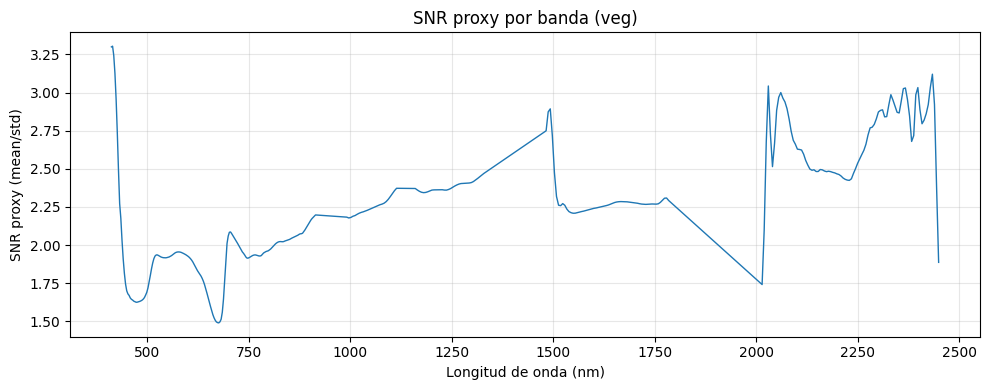

In [ ]:
# --- 5) SNR proxy por banda (sólo vegetación) ---
cube_veg = refl_byx.where(veg_mask & (mask_nodata == 0), np.nan)

with ProgressBar():
    band_mean = cube_veg.mean(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_std = cube_veg.std(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_max = cube_veg.max(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_min = cube_veg.min(dim=("y","x"), skipna=True).compute().values

snr_proxy = band_mean / np.where(band_std == 0, np.nan, band_std)
snr_df = pd.DataFrame({
    "band_index": np.arange(refl_byx.sizes["band"]),
    "wavelength_nm": wavelengths,
    "fwhm_nm": fwhm,
    "mean": band_mean,
    "std": band_std,
    "max": band_max,
    "min": band_min,
    "snr_proxy": snr_proxy
})
snr_df.to_csv(INTERIM_DATA + "/snr_proxy_per_band.csv", index=False)

plt.figure(figsize=(10,4))
plt.plot(wavelengths, snr_proxy, lw=1)
plt.xlabel("Longitud de onda (nm)"); plt.ylabel("SNR proxy (mean/std)")
plt.title("SNR proxy por banda (veg)"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/snr_proxy_curve.png", dpi=150)

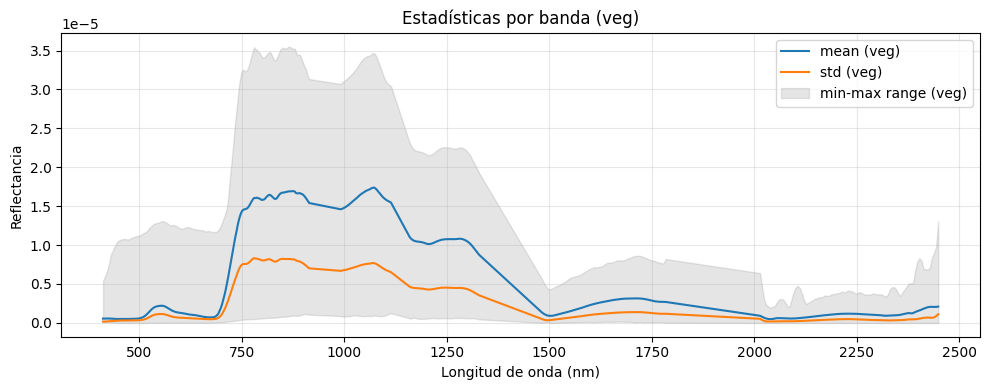

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, band_mean, label='mean (veg)')
plt.plot(wavelengths, band_std, label='std (veg)')
plt.fill_between(wavelengths, band_min, band_max, color='gray', alpha=0.2, label='min-max range (veg)')
plt.ylabel("Reflectancia")
plt.xlabel("Longitud de onda (nm)")
plt.title('Estadísticas por banda (veg)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/mean_std.png", dpi=150)

El SNR proxy establece un punto de referencia para evaluar aquellas bandas que podrían presentar problemas de calidad en función de su relación señal/ruido estimada. Cabe la pena mencionar que este SNR proxy solo es una representación para entender el comportamiento y que en ningún caso debe tomarse como un SNR físico del sensor.

Como se observa en su formulación (promedio de reflectancia/ desviación estandar de reflectancia), el proxy busca establecer una relación entre el comportamiento medio de la data comparado contra la variabilidad, que podría deberse a rudio. El objeto de analizar este gráfico es establecer si existen bandas que por su alto contenido de ruido puedan ser difíciles de emplear dentro del próximo modelado. Así pues, podemos sacar las siguientes observaciones a partir del análisis:

1. Entre 400 a 500 nm
Se observa un pico inicial seguido de una caída pronunciada. Este comportamiento indica que, aunque la media de reflectancia en la primera banda es muy baja, la desviación estándar es aún menor, lo que genera un SNR proxy artificialmente alto. Posteriormente, la caída refleja que en la región azul la señal es débil y la variabilidad relativa aumenta, probablemente por efectos de sombras y sensibilidad atmosférica. Estas bandas son menos confiables para modelado directo y conviene usarlas solo en índices robustos o descartarlas.

2. Región roja (650–690 nm)
Aquí se aprecia un valle marcado en el SNR proxy, coherente con la fuerte absorción de clorofila que reduce la media de reflectancia mientras la desviación estándar se mantiene relativamente alta. Esto implica que estas bandas presentan baja estabilidad espectral y podrían introducir ruido en modelos basados en reflectancia directa. Sin embargo, son críticas para índices como NDVI, por lo que se **debe considerar** mantenerlas en índices pero no como variables independientes.

3. Red-edge (705–740 nm)
En esta zona el SNR proxy mejora significativamente, lo que coincide con el incremento abrupto en la media de reflectancia y una desviación estándar moderada. Estas bandas son altamente informativas para evaluar vigor y contenido de clorofila, y además presentan buena estabilidad relativa, por lo que deben priorizarse en el modelado.

4. Meseta NIR (800–1300 nm)
El SNR proxy se mantiene en valores intermedios (≈2.2–2.8), reflejando una media alta y una desviación estándar estable. Esta región es confiable y aporta información sobre estructura foliar y biomasa, por lo que es recomendable conservarla en su totalidad para el modelado.

5. Bordes de ventanas de agua (~1500 nm y ~2000 nm)
Se observan quiebres abruptos en el SNR proxy, asociados a cambios bruscos en la media y la desviación estándar cerca de las zonas de absorción del agua. Aunque las ventanas principales fueron excluidas, los bordes pueden presentar inestabilidad, por lo que se sugiere aplicar márgenes de seguridad (±10–20 nm) al seleccionar bandas.

6. Región SWIR (2000–2400 nm)
El SNR proxy aumenta nuevamente y alcanza valores superiores a 3 en algunas bandas, lo que indica menor variabilidad relativa en vegetación. Estas bandas son útiles para evaluar estrés hídrico y contenido de lignina/celulosa, pero se debe verificar la cobertura válida por banda para evitar sesgos por píxeles escasos.

In [23]:
# --- 6) Correlación entre bandas contiguas ---
# Muestreo de píxeles de vegetación para controlar RAM
sample_fraction = 0.02
veg_coords = np.column_stack(np.where(to_numpy(veg_mask)))
n_veg = veg_coords.shape[0]
n_sample = max(5000, int(sample_fraction * n_veg))
idx_sel = RNG.choice(n_veg, size=n_sample, replace=False)
ys, xs = veg_coords[idx_sel, 0], veg_coords[idx_sel, 1]

spec_stack = refl_byx.isel(y=xr.DataArray(ys, dims="points"),
                           x=xr.DataArray(xs, dims="points")).transpose("points","band")
spec_np = spec_stack.astype("float32").values

adj_corr = np.full(refl_byx.sizes["band"]-1, np.nan, dtype="float32")
for k in range(refl_byx.sizes["band"]-1):
    a, b = spec_np[:, k], spec_np[:, k+1]
    m = (~np.isnan(a)) & (~np.isnan(b))
    if m.sum() > 10:
        adj_corr[k] = np.corrcoef(a[m], b[m])[0,1]

corr_df = pd.DataFrame({
    "band_k": np.arange(refl_byx.sizes["band"]-1),
    "wl_k_nm": wavelengths[:-1],
    "wl_k1_nm": wavelengths[1:],
    "adjacent_corr": adj_corr
})
corr_df.to_csv(REPORTS_DIR + "/adjacent_corr.csv", index=False)


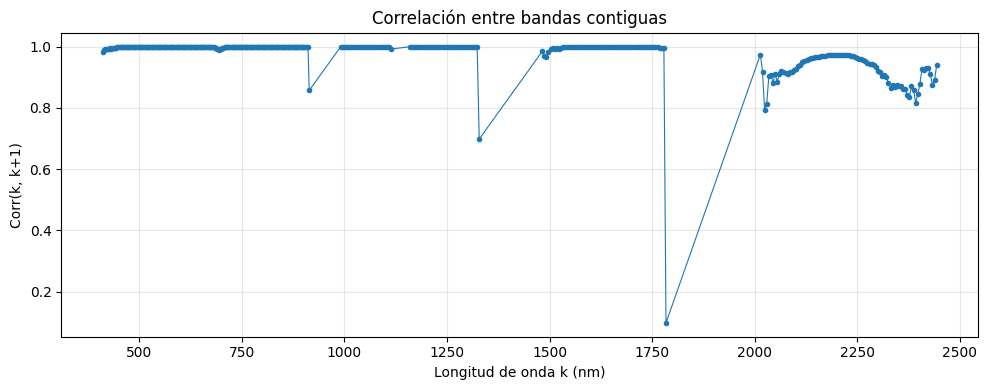

In [24]:
plt.figure(figsize=(10,4))
plt.plot(wavelengths[:-1], adj_corr, lw=0.8, marker='.')
plt.xlabel("Longitud de onda k (nm)"); plt.ylabel("Corr(k, k+1)")
plt.title("Correlación entre bandas contiguas"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_FOLDER + "/adjacent_corr_curve.png", dpi=150); plt.show()

- VNIR y NIR (≈400–1300 nm): correlación muy alta (≈0.98–1) dentro de segmentos → fuerte redundancia; puedes submuestrear sin perder demasiada información.
- Tramos cercanos a 700–740 nm (red‑edge): pequeños valles locales coherentes con cambios espectrales rápidos → conservar mayor resolución espectral aquí.
- Bordes de 1.4 µm y 1.9 µm: caídas no físicas por saltos (bandas de agua excluidas). Es incorrecto interpretarlas como descorrelación intrínseca; son pares no contiguos en λ.
- SWIR útil (≈2100–2350 nm): correlaciones altas pero algo más variables → informativo para lignina/celulosa/agua; conservar parte, evitando los bordes del gap de 1.9 µm.

Conclusión: para que la métrica sea interpretable, debemos limitar el cálculo a segmentos con Δλ “pequeño y regular” y documentar los gaps.

In [26]:
# --- A) Detectar segmentos espectrales continuos ---
from pathlib import Path
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


# Paso espectral
dwl = np.diff(wavelengths)  # nm entre bandas vecinas en el Zarr
median_step = float(np.nanmedian(dwl))
# Umbral para considerar GAP (pares no contiguos "reales"):
MAX_STEP = 2.5 * median_step

# Encuentra índices donde hay gap grande
gap_idx = np.where(dwl > MAX_STEP)[0]  # el corte está ENTRE k y k+1
# Construye segmentos [start_idx, end_idx] inclusive sobre índices de banda
segments = []
start = 0
for gi in gap_idx:
    segments.append((start, gi))   # cierre del segmento previo
    start = gi + 1                 # inicio del siguiente
segments.append((start, len(wavelengths)-1))  # último segmento

seg_df = pd.DataFrame([
    {
        "seg_id": s,
        "band_start": a,
        "band_end": b,
        "wl_start_nm": float(wavelengths[a]),
        "wl_end_nm": float(wavelengths[b]),
        "n_bands": int(b-a+1),
        "median_step_nm": float(np.nanmedian(np.diff(wavelengths[a:b+1]))) if (b-a)>=1 else np.nan
    }
    for s, (a,b) in enumerate(segments)
])
seg_df.to_csv(REPORTS_DIR + "/spectral_segments.csv", index=False)
seg_df

,seg_id,band_start,band_end,wl_start_nm,wl_end_nm,n_bands,median_step_nm
0,0,0,173,411.031830,913.989197,174,2.907288
1,1,174,198,990.878235,1113.687622,25,5.117065
2,2,199,232,1159.741089,1328.604004,34,5.117065
3,3,233,292,1482.115723,1784.021973,60,5.117065
4,4,293,378,2014.289551,2449.239502,86,5.116943


Reducción dimensional informada por segmento

- seg0 (411–914, Δλ≈2.9 nm): es claramente sobresampleado (tu FWHM ~3.8 nm). Muestrear cada ≈15–25 nm sin perder prácticamente información para ML tradicional.
- seg1–seg3 (991–1784, Δλ≈5.1 nm): submuestrear cada ≈20–30 nm es razonable; conserva red‑edge con un poco más de densidad si el SNR lo permite.
- seg4 (2014–2449, Δλ≈5.1 nm): No hacer submuestreo agresivo; usar ≈10–15 nm y evitar ±15–20 nm alrededor del borde de 1.9 µm (ya fuera del segmento, pero sus bordes afectan).

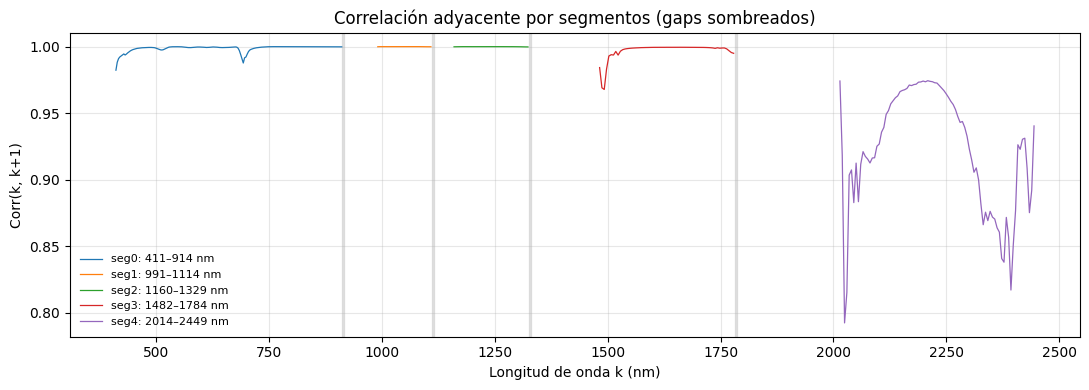

In [31]:
# --- B) Corr(k,k+1) limpia por segmento ---
RNG = np.random.default_rng(42)

# Muestreo de vegetación para controlar RAM
veg_coords = np.column_stack(np.where(veg_mask.values))
n_veg = veg_coords.shape[0]
n_sample = max(5000, int(0.02 * n_veg))
idx_sel = RNG.choice(n_veg, size=n_sample, replace=False)
ys, xs = veg_coords[idx_sel, 0], veg_coords[idx_sel, 1]

# Extrae espectros (N, B)
spec_stack = refl_byx.isel(y=xr.DataArray(ys, dims="points"),
                           x=xr.DataArray(xs, dims="points")).transpose("points","band")
X = spec_stack.astype("float32").values

rows = []
for seg_id, (a,b) in enumerate(segments):
    if b <= a: 
        continue
    for k in range(a, b):  # solo dentro del segmento
        a_k, b_k = X[:, k], X[:, k+1]
        m = np.isfinite(a_k) & np.isfinite(b_k)
        n = int(m.sum())
        corr = np.corrcoef(a_k[m], b_k[m])[0,1] if n > 50 else np.nan
        rows.append({
            "seg_id": seg_id,
            "band_k": k,
            "wl_k_nm": float(wavelengths[k]),
            "wl_k1_nm": float(wavelengths[k+1]),
            "delta_nm": float(wavelengths[k+1]-wavelengths[k]),
            "n_valid": n,
            "adjacent_corr": corr
        })

adj_clean = pd.DataFrame(rows)
adj_clean.to_csv(REPORTS_DIR + "/adjacent_corr_by_segment.csv", index=False)

# Plot segmentado
plt.figure(figsize=(11,4))
for seg_id, g in adj_clean.groupby("seg_id"):
    seg_start_wl = seg_df.loc[seg_id, "wl_start_nm"]
    seg_end_wl = seg_df.loc[seg_id, "wl_end_nm"]
    text_segs = f"seg{seg_id}: {seg_start_wl:.0f}–{seg_end_wl:.0f} nm"
    plt.plot(g["wl_k_nm"], g["adjacent_corr"], lw=0.9, label=text_segs)
# sombrear gaps
for gi in gap_idx:
    x = wavelengths[gi]
    plt.axvspan(x-2, x+2, color="gray", alpha=0.2)
plt.xlabel("Longitud de onda k (nm)"); plt.ylabel("Corr(k, k+1)")
plt.title("Correlación adyacente por segmentos (gaps sombreados)")
plt.grid(True, alpha=0.3); plt.legend(ncol=1, fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(FIGURES_FOLDER + "/adjacent_corr_by_segment.png", dpi=150); plt.show()


In [32]:
# Requiere: segments, wavelengths, X (espectros muestreados N×B) del paso previo
max_lag = 12  # ~ hasta 60 nm en segmentos con paso ~5 nm
decor_rows = []
for seg_id, (a,b) in enumerate(segments):
    if (b - a) < 2: continue
    for lag in range(1, min(max_lag, b-a)+1):
        vals, dls = [], []
        for k in range(a, b-lag+1):
            dlam = wavelengths[k+lag] - wavelengths[k]
            a_k, b_k = X[:, k], X[:, k+lag]
            m = np.isfinite(a_k) & np.isfinite(b_k)
            if m.sum() > 50:
                vals.append(np.corrcoef(a_k[m], b_k[m])[0,1])
                dls.append(dlam)
        if vals:
            decor_rows.append({"seg_id": seg_id,
                               "lag": lag,
                               "median_delta_nm": float(np.median(dls)),
                               "median_corr": float(np.median(vals))})
decor_df = pd.DataFrame(decor_rows)
decor_df.to_csv(REPORTS_DIR + "/corr_vs_dlambda_by_segment.csv", index=False)

def L_at(g, thr):
    g = g.sort_values("median_delta_nm")
    # interpola longitud cuando la correlación mediana cruza el umbral
    return float(np.interp(thr, g["median_corr"][::-1], g["median_delta_nm"][::-1],
                           left=np.nan, right=np.nan))

summary = []
for seg_id, g in decor_df.groupby("seg_id"):
    summary.append({
        "seg_id": seg_id,
        "L95_nm": L_at(g, 0.95),
        "L90_nm": L_at(g, 0.90),
    })
summary_df = pd.DataFrame(summary)
summary_df.to_csv(REPORTS_DIR + "/decorrelation_length_summary.csv", index=False)
summary_df

,seg_id,L95_nm,L90_nm
0,0,NaN,NaN
1,1,NaN,NaN
2,2,NaN,NaN
3,3,NaN,NaN
4,4,NaN,6.245494


In [33]:
# --- Decorrelación robusta: mayor max_lag + límites cuando no hay cruce ---
import numpy as np
import pandas as pd

# decor_df: median_corr vs median_delta_nm por segmento (ya calculado)
def length_at_threshold(g, thr):
    g = g.dropna().sort_values("median_delta_nm")
    x = g["median_delta_nm"].values
    y = g["median_corr"].values

    if len(x) < 2 or np.all(np.isnan(y)):
        return np.nan, "no-data"

    if np.nanmin(y) > thr:
        # nunca cruza: correlación siempre > thr -> sólo tenemos un L mínimo
        return float(x[-1]), ">=max"   # lower bound: L_thr es mayor que este máximo probado
    if np.nanmax(y) < thr:
        # ya está por debajo desde el inicio -> upper bound
        return float(x[0]), "<=min"

    # cruce por interpolación
    # Asegura monotonicidad aproximada con un suavizado ligero si es necesario
    idx = np.argsort(x); x, y = x[idx], y[idx]
    # buscar el primer cruce descendente
    for i in range(1, len(x)):
        if (y[i-1] >= thr) and (y[i] <= thr):
            # interpolación lineal
            t = (thr - y[i-1]) / (y[i] - y[i-1] + 1e-12)
            return float(x[i-1] + t*(x[i]-x[i-1])), "hit"
    return np.nan, "nan"

# Recomiendo subir max_lag
max_lag = 40  # p.ej., ~200 nm para paso 5 nm; ajusta según compute budget

# ... (recalcula decor_df con este max_lag) ...

summary = []
for seg_id, g in decor_df.groupby("seg_id"):
    L95, s95 = length_at_threshold(g, 0.95)
    L90, s90 = length_at_threshold(g, 0.90)
    summary.append({"seg_id": seg_id, "L95_nm": L95, "L95_status": s95,
                    "L90_nm": L90, "L90_status": s90})
summary_df = pd.DataFrame(summary)
summary_df


,seg_id,L95_nm,L95_status,L90_nm,L90_status
0,0,34.887207,>=max,34.887207,>=max
1,1,61.404663,>=max,61.404663,>=max
2,2,61.404663,>=max,61.404663,>=max
3,3,61.404663,>=max,61.404663,>=max
4,4,5.116943,<=min,6.245494,hit


In [37]:
for thr in [0.99, 0.975, 0.95, 0.90]:
    L, st = length_at_threshold(g, thr)
    print(thr, L, st)
    # guarda el primer umbral que cruce

0.99 5.116943359375 <=min
0.975 5.116943359375 <=min
0.95 5.116943359375 <=min
0.9 6.245494375036131 hit


- L95_nm / L90_nm = mínima separación en nm a la que la correlación mediana entre bandas cae por debajo de 0.95 (o 0.90), dentro de cada segmento continuo (sin gaps).
- ">= max: ni siquiera con el máximo lag evaluado la correlación bajó del umbral ⇒ decorrelación muy lenta (altísima redundancia).
- <=min: ya en el primer lag (paso mínimo de tu segmento) la correlación está por debajo del umbral ⇒ decorrelación muy rápida (baja redundancia).
- hit: el cruce ocurrió dentro del rango evaluado ⇒ puedes usar ese L como espaciamiento objetivo.

Conclusión: seg0–seg3 están sobre‑muestreados en relación con su variabilidad espectral (corr adyacente ~1 incluso a decenas de nm). seg4 sí cambia rápido: a ~6.2 nm ya cae por debajo de 0.9 ⇒ ahí no conviene comprimir fuerte.

2) N.º efectivo de bandas aproximado (ENB)
ENB ≲ ancho_segmento / L95 (a mayor L95, menos bandas “independientes”).

- seg0: 503 nm / ≥34.9 ≲ ≤14–15
- seg1: 123 nm / ≥61.4 ≲ ≤2
- seg2: 169 nm / ≥61.4 ≲ ≤3
- seg3: 302 nm / ≥61.4 ≲ ≤5
- seg4: 435 nm / ≈6.25 ≳ ≥70 (mucha estructura)

Conclusión: donde la curva tenía “plato” (seg0–3), basta un submuestreo agresivo; en seg4 sí se necesita una malla densa.

3) Recomendación de espaciamiento por segmento (para selección inicial)

Integrar también SNR proxy y cobertura válida (valid_ratio) como filtros.

- seg0 (411–914): usar ≈30–40 nm (más denso 10–15 nm sólo en ~700–740 nm por red‑edge).
- seg1 (991–1114): ≈30–40 nm.
- seg2 (1160–1329): ≈25–35 nm.
- seg3 (1482–1784): ≈30–40 nm; evitar las primeras ~15–20 nm por cercanía al borde de 1.4 µm.
- seg4 (2014–2449): ≈6–10 nm; evitar 2014–2050 nm (borde 1.9 µm). Parea compactar aún más después, pasar a ≈12 nm.

Dos perfiles prácticos

Perfil compacto (≈59–60 antes de filtrar por SNR/valid.):
- seg0: 40 nm (≈12), 
- seg1: 40 nm (≈3), 
- seg2: 35 nm (≈4–5), 
- seg3: 40 nm (≈7), 
- seg4: 12 nm (≈33)

Perfil rico (~80–95 bandas):
- seg0: 25 nm (≈20) con 15 nm en red‑edge (añade 2–3), -
- seg1: 30 nm (≈4), 
- seg2: 25–30 nm (≈6–7), 
- seg3: 30 nm (≈10–11), 
- seg4: 8–10 nm (≈40–50)

In [ ]:
# --- Selección de bandas parametrizada por segmento (con prints útiles) ---
from pathlib import Path
import numpy as np
import pandas as pd

# Configuración de logging simple
verbose = True          # activa prints detallados
print_every = 10        # imprime cada N bandas evaluadas por segmento para no saturar

# Lectura de SNR
snr_path = Path(INTERIM_DATA) / "snr_proxy_per_band.csv"
snr = pd.read_csv(snr_path)["snr_proxy"].values  # ojo: .values, no .value

# Cobertura válida en vegetación
print("[INFO] Calculando cobertura válida (valid_ratio) por banda en vegetación...")
valid_ratio = np.zeros(refl_byx.sizes["band"], dtype=float)
for k in range(refl_byx.sizes["band"]):
    print(f"[INFO] Procesando banda {k+1}/{refl_byx.sizes['band']}...")
    arr = refl_byx.isel(band=k).values
    m = np.isfinite(arr) & veg_mask.values
    valid_ratio[k] = m.mean()
if verbose:
    print(f"[INFO] Cobertura válida (mediana): {np.nanmedian(valid_ratio):.2%}")

In [41]:
valid_ratio

array([0.48700247, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700255, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700

In [46]:
# Parámetros
L_target = {0: 25.0, 1: 35.0, 2: 30.0, 3: 30.0, 4: 8.0}    # nm de espaciamiento por segmento
MARGIN_NEAR_GAPS = {3: (15.0, 10.0), 4: (36.0, 20.0)}      # (left_cut, right_cut) en nm
MIN_VALID = 0.48

MAX_PAIR_CORR_SEG = {
    0: 0.9995,  # VNIR denso
    1: 0.9995,
    2: 0.9995,
    3: 0.9995,
    4: 0.98     # SWIR útil: mantener control
}

MIN_PAIR_VALID = 50
snr_q25 = np.nanquantile(snr, 0.25)

if verbose:
    print("[INFO] Parámetros:")
    print(f"       MIN_VALID={MIN_VALID:.2f}, MAX_PAIR_CORR={MAX_PAIR_CORR:.3f}, "
          f"MIN_PAIR_VALID={MIN_PAIR_VALID}, snr_q25={snr_q25:.3f}")
    print(f"       L_target por segmento: {L_target}")
    print(f"       Márgenes cerca de gaps: {MARGIN_NEAR_GAPS}")

selected = []
reasons = []

# tqdm opcional
try:
    from tqdm import tqdm
    segments_iter = tqdm(list(enumerate(segments)), desc="Segmentos", leave=True)
except Exception:
    segments_iter = list(enumerate(segments))

for seg_id, (a, b) in segments_iter:
    MAX_PAIR_CORR = MAX_PAIR_CORR_SEG.get(seg_id, 0.99)
    wl_start, wl_end = float(wavelengths[a]), float(wavelengths[b])
    L = L_target.get(seg_id, 30.0)
    left_cut, right_cut = MARGIN_NEAR_GAPS.get(seg_id, (0.0, 0.0))

    if verbose:
        print(f"\n[SEG {seg_id}] λ≈{wl_start:.1f}–{wl_end:.1f} nm, "
              f"bandas={b-a+1}, L_target={L:.1f} nm, margen=({left_cut:.1f},{right_cut:.1f}) nm")

    # 1) Candidatas tras filtros “duros”: margen, valid_ratio, SNR
    idxs = []
    for i in range(a, b + 1):
        wl_i = float(wavelengths[i])

        # Márgenes a gaps (inicio/fin del segmento)
        if (wl_i - wl_start) < left_cut:
            reasons.append({"band_index": i, "reason": "near_left_gap", "seg_id": seg_id})
            continue
        if (wl_end - wl_i) < right_cut:
            reasons.append({"band_index": i, "reason": "near_right_gap", "seg_id": seg_id})
            continue

        # Cobertura y SNR
        if (not np.isfinite(valid_ratio[i])) or (valid_ratio[i] < MIN_VALID):
            reasons.append({"band_index": i, "reason": "low_valid", "seg_id": seg_id})
            continue
        if (not np.isfinite(snr[i])) or (snr[i] < snr_q25):
            reasons.append({"band_index": i, "reason": "low_snr", "seg_id": seg_id})
            continue

        idxs.append(i)

    if verbose:
        print(f"[SEG {seg_id}] Candidatas tras filtros: {len(idxs)} / {b-a+1} "
              f"(≥{MIN_VALID:.0%} válidos & SNR≥Q25 & márgenes)")

    if not idxs:
        print(f"[SEG {seg_id}] ⚠️  Sin candidatas, se omite segmento.")
        continue

    # 2) Orden por SNR (con posible bonus si quieres densidad extra en red-edge)
    def score(i):
        wl_i = float(wavelengths[i])
        bonus = 0.0  # p.ej., 0.1 si 700<=wl_i<=740 para favorecer red-edge
        return (snr[i] if np.isfinite(snr[i]) else -np.inf) + bonus

    order = sorted(idxs, key=lambda k: score(k), reverse=True)
    if verbose:
        top5 = [(int(i), float(wavelengths[i]), float(snr[i]), float(valid_ratio[i])) for i in order[:5]]
        print(f"[SEG {seg_id}] Top-5 por SNR (idx, nm, SNR, valid): {top5}")

    # 3) Selección greedy: respeta espaciamiento en nm y límite de correlación a pares
    keep = []
    evaluated = 0
    for i in order:
        wl_i = float(wavelengths[i])

        # Espaciado en λ con lo ya seleccionado del segmento
        if any(abs(wl_i - float(wavelengths[j])) < 0.7 * L for j in keep):
            reasons.append({"band_index": i, "reason": "spacing", "seg_id": seg_id})
            evaluated += 1
            if verbose and evaluated % print_every == 0:
                print(f"[SEG {seg_id}] Evaluadas {evaluated}/{len(order)}... descarta por spacing: "
                      f"idx {i}, λ={wl_i:.1f} nm")
            continue

        # Correlación a pares con muestra X (evitar colinealidad extrema)
        ok = True
        for j in keep:
            a_i, a_j = X[:, i], X[:, j]
            m = np.isfinite(a_i) & np.isfinite(a_j)
            n = int(m.sum())
            if n > MIN_PAIR_VALID:
                c = np.corrcoef(a_i[m], a_j[m])[0, 1]
                if c > MAX_PAIR_CORR:
                    ok = False
                    reasons.append({"band_index": i, "reason": f"pair_corr>{MAX_PAIR_CORR}", "seg_id": seg_id})
                    if verbose:
                        print(f"[SEG {seg_id}] Descartada por correlación a pares: "
                              f"idx {i} (λ={wl_i:.1f} nm) vs {j} (λ={float(wavelengths[j]):.1f} nm), "
                              f"corr={c:.3f}, n={n}")
                    break

        if ok:
            keep.append(i)
            if verbose:
                print(f"[SEG {seg_id}] ✅ Seleccionada: idx {i} | λ={wl_i:.1f} nm | "
                      f"SNR={snr[i]:.3f} | valid={valid_ratio[i]:.2%} | sel_seg={len(keep)}")

        evaluated += 1
        if verbose and evaluated % print_every == 0:
            print(f"[SEG {seg_id}] Progreso selección: {evaluated}/{len(order)} evaluadas, {len(keep)} elegidas.")

    # 4) Persistir selección del segmento
    for i in sorted(keep):
        selected.append({
            "seg_id": seg_id,
            "band_index": int(i),
            "wavelength_nm": float(wavelengths[i]),
            "snr_proxy": float(snr[i]),
            "valid_ratio_veg": float(valid_ratio[i])
        })

    print(f"[SEG {seg_id}] ✔️  Seleccionadas en segmento: {len(keep)} "
          f"(λ: {float(wavelengths[keep[0]]):.1f}–{float(wavelengths[keep[-1]]):.1f} nm)" 
          if keep else f"[SEG {seg_id}] ⚠️  No se seleccionaron bandas.")

# 5) Salidas y resumen global
sel_df = pd.DataFrame(selected)
reasons_df = pd.DataFrame(reasons)

sel_path = INTERIM_DATA + "/bands_selected_by_segment.csv"
reasons_path = INTERIM_DATA + "/bands_selection_reasons.csv"
sel_df.to_csv(sel_path, index=False)
reasons_df.to_csv(reasons_path, index=False)

print("\n[RESUMEN] Bandas seleccionadas totales:", len(sel_df))
if len(sel_df):
    print(sel_df.groupby("seg_id").size())

print(f"[RESUMEN] Guardado: {sel_path}")
print(f"[RESUMEN] Guardado (razones de descarte): {reasons_path}")

[INFO] Parámetros:
       MIN_VALID=0.48, MAX_PAIR_CORR=1.000, MIN_PAIR_VALID=50, snr_q25=1.938
       L_target por segmento: {0: 25.0, 1: 35.0, 2: 30.0, 3: 30.0, 4: 8.0}
       Márgenes cerca de gaps: {3: (15.0, 10.0), 4: (36.0, 20.0)}


Segmentos:   0%|          | 0/5 [00:00<?, ?it/s]


[SEG 0] λ≈411.0–914.0 nm, bandas=174, L_target=25.0 nm, margen=(0.0,0.0) nm
[SEG 0] Candidatas tras filtros: 81 / 174 (≥48% válidos & SNR≥Q25 & márgenes)
[SEG 0] Top-5 por SNR (idx, nm, SNR, valid): [(1, 413.9390869140625, 3.304166, 0.487002625748227), (0, 411.0318298339844, 3.2992928, 0.4870024668046297), (2, 416.8463439941406, 3.2435493, 0.487002625748227), (3, 419.7536315917969, 3.1265423, 0.487002625748227), (4, 422.660888671875, 2.9570558, 0.487002625748227)]
[SEG 0] ✅ Seleccionada: idx 1 | λ=413.9 nm | SNR=3.304 | valid=48.70% | sel_seg=1
[SEG 0] ✅ Seleccionada: idx 173 | λ=914.0 nm | SNR=2.197 | valid=48.70% | sel_seg=2
[SEG 0] Evaluadas 10/81... descarta por spacing: idx 172, λ=911.1 nm
[SEG 0] ✅ Seleccionada: idx 8 | λ=434.3 nm | SNR=2.176 | valid=48.70% | sel_seg=3
[SEG 0] ✅ Seleccionada: idx 166 | λ=893.6 nm | SNR=2.125 | valid=48.70% | sel_seg=4
[SEG 0] Evaluadas 20/81... descarta por spacing: idx 163, λ=884.9 nm
[SEG 0] ✅ Seleccionada: idx 101 | λ=704.7 nm | SNR=2.085 | v

Segmentos:  20%|██        | 1/5 [00:00<00:02,  1.46it/s]

[SEG 0] ✅ Seleccionada: idx 128 | λ=783.2 nm | SNR=1.939 | valid=48.70% | sel_seg=10
[SEG 0] ✔️  Seleccionadas en segmento: 10 (λ: 413.9–783.2 nm)

[SEG 1] λ≈990.9–1113.7 nm, bandas=25, L_target=35.0 nm, margen=(0.0,0.0) nm
[SEG 1] Candidatas tras filtros: 25 / 25 (≥48% válidos & SNR≥Q25 & márgenes)
[SEG 1] Top-5 por SNR (idx, nm, SNR, valid): [(198, 1113.6876220703125, 2.3720644, 0.487002625748227), (197, 1108.570556640625, 2.3565507, 0.487002625748227), (196, 1103.4534912109375, 2.3378744, 0.487002625748227), (195, 1098.33642578125, 2.318103, 0.487002625748227), (194, 1093.2193603515625, 2.299686, 0.487002625748227)]
[SEG 1] ✅ Seleccionada: idx 198 | λ=1113.7 nm | SNR=2.372 | valid=48.70% | sel_seg=1
[SEG 1] ✅ Seleccionada: idx 193 | λ=1088.1 nm | SNR=2.285 | valid=48.70% | sel_seg=2
[SEG 1] Evaluadas 10/25... descarta por spacing: idx 189, λ=1067.6 nm
[SEG 1] Descartada por correlación a pares: idx 188 (λ=1062.5 nm) vs 193 (λ=1088.1 nm), corr=1.000, n=122559
[SEG 1] Descartada por c

...

[SEG 2] ✅ Seleccionada: idx 209 | λ=1210.9 nm | SNR=2.362 | valid=48.70% | sel_seg=5
[SEG 2] Descartada por correlación a pares: idx 214 (λ=1236.5 nm) vs 222 (λ=1277.4 nm), corr=1.000, n=122559
[SEG 2] Evaluadas 30/34... descarta por spacing: idx 201, λ=1170.0 nm
[SEG 2] Descartada por correlación a pares: idx 204 (λ=1185.3 nm) vs 209 (λ=1210.9 nm), corr=1.000, n=122559
[SEG 2] ✔️  Seleccionadas en segmento: 5 (λ: 1328.6–1210.9 nm)

[SEG 3] λ≈1482.1–1784.0 nm, bandas=60, L_target=30.0 nm, margen=(15.0,10.0) nm
[SEG 3] Candidatas tras filtros: 55 / 60 (≥48% válidos & SNR≥Q25 & márgenes)
[SEG 3] Top-5 por SNR (idx, nm, SNR, valid): [(236, 1497.4669189453125, 2.7166593, 0.487002625748227), (237, 1502.5838623046875, 2.4749935, 0.4870024668046297), (238, 1507.7010498046875, 2.318658, 0.48699897004548964), (290, 1773.787841796875, 2.3069305, 0.487002625748227), (289, 1768.6708984375, 2.2935781, 0.487002625748227)]
[SEG 3] ✅ Seleccionada: idx 236 | λ=1497.5 nm | SNR=2.717 | valid=48.70% | sel

Segmentos:  80%|████████  | 4/5 [00:01<00:00,  3.61it/s]

[SEG 3] ✅ Seleccionada: idx 259 | λ=1615.2 nm | SNR=2.250 | valid=48.70% | sel_seg=9
[SEG 3] Evaluadas 40/55... descarta por spacing: idx 258, λ=1610.0 nm
[SEG 3] ✅ Seleccionada: idx 254 | λ=1589.6 nm | SNR=2.234 | valid=48.70% | sel_seg=10
[SEG 3] Evaluadas 50/55... descarta por spacing: idx 250, λ=1569.1 nm
[SEG 3] ✅ Seleccionada: idx 249 | λ=1564.0 nm | SNR=2.216 | valid=48.70% | sel_seg=11
[SEG 3] ✔️  Seleccionadas en segmento: 11 (λ: 1497.5–1564.0 nm)

[SEG 4] λ≈2014.3–2449.2 nm, bandas=86, L_target=8.0 nm, margen=(36.0,20.0) nm
[SEG 4] Candidatas tras filtros: 74 / 86 (≥48% válidos & SNR≥Q25 & márgenes)
[SEG 4] Top-5 por SNR (idx, nm, SNR, valid): [(374, 2428.771240234375, 3.033131, 0.486974333787912), (368, 2398.06884765625, 3.0325649, 0.48693165743204364), (362, 2367.366455078125, 3.0299113, 0.4869503333047235), (361, 2362.24951171875, 3.0255935, 0.48695589633062814), (302, 2060.343017578125, 2.9998322, 0.48699006920404225)]
[SEG 4] ✅ Seleccionada: idx 374 | λ=2428.8 nm | SNR=3

Segmentos: 100%|██████████| 5/5 [00:04<00:00,  1.20it/s]

[SEG 4] ✅ Seleccionada: idx 333 | λ=2219.0 nm | SNR=2.431 | valid=48.70% | sel_seg=35
[SEG 4] ✅ Seleccionada: idx 335 | λ=2229.2 nm | SNR=2.424 | valid=48.70% | sel_seg=36
[SEG 4] ✔️  Seleccionadas en segmento: 36 (λ: 2428.8–2229.2 nm)

[RESUMEN] Bandas seleccionadas totales: 66
seg_id
0    10
1     4
2     5
3    11
4    36
dtype: int64
[RESUMEN] Guardado: c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\interim\/bands_selected_by_segment.csv
[RESUMEN] Guardado (razones de descarte): c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\interim\/bands_selection_reasons.csv


In [ ]:
# --- 7) Quicklook RGB ---
target_rgb = {"R": 665, "G": 560, "B": 490}
idx_r, r_nm = nearest_band_index(wavelengths, target_rgb["R"])
idx_g, g_nm = nearest_band_index(wavelengths, target_rgb["G"])
idx_b, b_nm = nearest_band_index(wavelengths, target_rgb["B"])

R = refl_byx.isel(band=idx_r); G = refl_byx.isel(band=idx_g); B = refl_byx.isel(band=idx_b)

def stretch(img, pmin=2, pmax=98):
    vmin = np.nanpercentile(to_numpy(img), pmin)
    vmax = np.nanpercentile(to_numpy(img), pmax)
    return ((img - vmin) / (vmax - vmin)).clip(0, 1)

rgb = xr.concat([stretch(R), stretch(G), stretch(B)], dim="channel")
rgb = rgb.isel(y=slice(None, None, 4), x=slice(None, None, 4))
rgb_np = np.moveaxis(to_numpy(rgb), 0, -1)

plt.figure(figsize=(8,8))
plt.imshow(rgb_np); plt.axis("off")
plt.title(f"Quicklook RGB ~ R{r_nm:.0f} G{g_nm:.0f} B{b_nm:.0f} nm")
plt.tight_layout(); 
# plt.savefig(REPORTS_DIR / "quicklook_rgb.png", dpi=150); plt.show()

TypeError: unhashable type: 'list'

In [ ]:
# --- 8) PCA (vegetación) ---
from sklearn.decomposition import IncrementalPCA

n_components = 3
sample_size = 200_000
if n_sample < sample_size:
    sample_size = n_sample

# Reutilizamos (ys, xs) si te sirve; si no, remuestrea:
idx_sel2 = RNG.choice(n_veg, size=sample_size, replace=False)
ys2, xs2 = veg_coords[idx_sel2, 0], veg_coords[idx_sel2, 1]

spec_stack2 = refl_byx.isel(y=xr.DataArray(ys2, dims="points"),
                            x=xr.DataArray(xs2, dims="points")).transpose("points","band")
X = spec_stack2.astype("float32").values

band_mean_all = np.nanmean(X, axis=0, dtype="float64")
Xc = X - band_mean_all

ipca = IncrementalPCA(n_components=n_components, batch_size=2000)
ipca.fit(Xc)

# Proyección a toda la escena (lazy)
components = ipca.components_.astype("float32")  # (pc, band)
cube_c = refl_byx - xr.DataArray(band_mean_all, dims=["band"])
pcs = []
for i in range(n_components):
    pcs.append((cube_c * xr.DataArray(components[i], dims=["band"])).sum(dim="band"))
pcs_da = xr.concat(pcs, dim="pc").transpose("pc","y","x").astype("float32")
pcs_da = pcs_da.assign_coords(pc=np.arange(1, n_components+1)).rename("PCA")

# Guardar
pcs_da.to_dataset().to_zarr(REPORTS_DIR / "pca_components.zarr", mode="w")
if RASTERIO_AVAILABLE:
    pcs_np = np.stack([to_numpy(pcs_da.isel(pc=i)) for i in range(n_components)], axis=0)
    # Helper propio (simple): escribir multibanda con rasterio
    profile = {
        "driver": "GTiff", "height": pcs_np.shape[1], "width": pcs_np.shape[2],
        "count": n_components, "dtype": "float32", "crs": crs, "transform": transform,
        "tiled": True, "compress": "deflate", "predictor": 2
    }
    with rasterio.open(REPORTS_DIR / "pca_components.tif", "w", **profile) as dst:
        for i in range(n_components):
            dst.write(pcs_np[i], i+1)

expl_var = ipca.explained_variance_ratio_.tolist()
pd.Series(expl_var, index=[f"PC{i+1}" for i in range(n_components)]).to_csv(REPORTS_DIR / "pca_explained_variance.csv")
print("Explained variance ratio:", [round(x,4) for x in expl_var])